In [3]:
import pandas as pd
import sqlite3

In [4]:
df = pd.read_csv(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.csv')
#aller dans le répertoire du fichier, faire clique droit et selectionner copier le chemin puis venir le coller ici sans oublier d'ajouter un r avant.


In [5]:
df.head(6)
#pour visualiser les 6 premiers lignes

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,28-Nov-15,43


In [130]:
df.tail(6)
#pour visualiser les 6 dernières

,uniqueID,drugName,condition,review,rating,date,usefulCount
161291,164345,Junel 1.5 / 30,Birth Control,"""This would be my second month on Junel. I&#03...",6,27-May-15,0
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adu...",9,13-Dec-14,116


In [131]:
df.shape
#pour connaitre le nombre de lignes et de colonne du dataframe

(161297, 7)

In [132]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
#pour établir la connection et pouvoir ouvrir le df
print("Connexion OK")

Connexion OK


In [133]:
df.to_sql('reviews', connexion, if_exists='replace', index=False)
#Une base de données nommé reviews a été créé
#index=false pour ne pas sauvegarder l'index Pandas (0, 1, 2...) comme colonne
#if_exists='replace' pour écraser la table si elle existe déja.
print("Base créée avec succès !")

Base créée avec succès !


In [134]:
resultat = pd.read_sql_query("SELECT drugName, condition, usefulCount, AVG(rating) as note_moyenne FROM reviews GROUP BY drugName ORDER BY note_moyenne DESC LIMIT 10", connexion)
#Une requete SQL pour visualiser comme je veux les données et ici je voulais visualiser les 10 medicaments avec un meilleur score moyen
print(resultat)

                          drugName                                condition  \
0                 Zyrtec-D 12 Hour                        Allergic Rhinitis   
1                           Zymine                                Allergies   
2                         Zutripro               Cough and Nasal Congestion   
3                         Zurampic                                     Gout   
4                          Zostrix                           Osteoarthritis   
5                       Zinc oxide                              Diaper Rash   
6  Zicam Extreme Congestion Relief                         Nasal Congestion   
7                           Zetran                                  Anxiety   
8                           Zenpep                     Chronic Pancreatitis   
9                          Zemaira  Alpha-1 Proteinase Inhibitor Deficiency   

   usefulCount  note_moyenne  
0           14          10.0  
1           11          10.0  
2            8          10.0  
3     

In [135]:
connexion.close()
#toujours fermer la connexion quand on a fini

In [136]:
#Importer tous les bibliothéques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Toutes les bibliothèques sont opérationnelles !")

Toutes les bibliothèques sont opérationnelles !


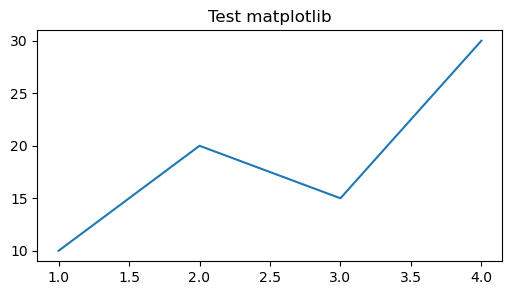

In [137]:
#test matplotlib rien à voir avec mes données
plt.figure(figsize=(6,3))
plt.plot([1,2,3,4], [10,20,15,30])
plt.title("Test matplotlib")
plt.show()

EXPLORATION DES DONNEES

In [6]:
df.dtypes

uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

In [12]:
df.isnull().sum()
#donc il y'a 899 lignes où la condition est manquante, pour les autres colonnes pas de cases vides

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [24]:
df['condition'].isnull().sum()
#juste une confirmation

np.int64(899)

In [17]:
df['condition'].nunique()
#il y'a 884 conditions différentes dans ce data

884

In [11]:
df['condition'].head(8)

0    Left Ventricular Dysfunction
1                            ADHD
2                   Birth Control
3                   Birth Control
4               Opiate Dependence
5    Benign Prostatic Hyperplasia
6         Emergency Contraception
7                 Bipolar Disorde
Name: condition, dtype: object

In [28]:
df['drugName'].nunique()

3436

In [27]:
df['rating'].value_counts()

rating
10    50989
9     27531
1     21619
8     18890
7      9456
5      8013
2      6931
3      6513
6      6343
4      5012
Name: count, dtype: int64

In [44]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
resultat = pd.read_sql_query("SELECT drugName, condition FROM reviews WHERE rating = 10 LIMIT 10", connexion)
print(resultat)
connexion.close()

         drugName                     condition
0    Aripiprazole               Bipolar Disorde
1  L-methylfolate                    Depression
2     Lamotrigine               Bipolar Disorde
3       Nilotinib  Chronic Myelogenous Leukemia
4       Trazodone                      Insomnia
5      Etanercept          Rheumatoid Arthritis
6    Eflornithine                     Hirsutism
7        Daytrana                          ADHD
8    Azithromycin                          None
9         Toradol                          Pain


In [41]:
df['date'].describe()

count       161297
unique        3579
top       1-Mar-16
freq           146
Name: date, dtype: object

In [42]:
df['rating'].describe()

count    161297.000000
mean          6.994377
std           3.272329
min           1.000000
25%           5.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: rating, dtype: float64

In [43]:
df['drugName'].describe()

count             161297
unique              3436
top       Levonorgestrel
freq                3657
Name: drugName, dtype: object

In [59]:
df['drugName'].value_counts()

drugName
Levonorgestrel                       3657
Etonogestrel                         3336
Ethinyl estradiol / norethindrone    2850
Nexplanon                            2156
Ethinyl estradiol / norgestimate     2117
                                     ... 
Omnipaque 350                           1
Vontrol                                 1
Ivabradine                              1
Neo-Poly-Dex                            1
Grifulvin V                             1
Name: count, Length: 3436, dtype: int64

In [53]:
connexion = sqlite3.connect(r'C:\Users\marie\OneDrive\Documents\GitHub\portfolio-data-ia-pharma\projet1-drug-data\data\drugsComTrain_raw.db')
df.to_sql('reviews', connexion, if_exists='replace', index=False)
resultat = pd.read_sql_query("SELECT rating, condition FROM reviews WHERE drugName = 'Levonorgestrel' LIMIT 10", connexion)
print(resultat)
connexion.close()

   rating                condition
0       1  Emergency Contraception
1       1            Birth Control
2      10            Birth Control
3       2            Birth Control
4       3            Birth Control
5      10            Birth Control
6       9  Emergency Contraception
7       4            Birth Control
8      10  Emergency Contraception
9      10            Birth Control


In [60]:
df['condition'].value_counts()

condition
Birth Control                                              28788
Depression                                                  9069
Pain                                                        6145
Anxiety                                                     5904
Acne                                                        5588
                                                           ...  
Dissociative Identity Disorde                                  1
Hydrocephalus                                                  1
Hyperlipoproteinemia Type III, Elevated beta-VLDL   IDL        1
Q Feve                                                         1
Neutropenia                                                    1
Name: count, Length: 884, dtype: int64

In [57]:
df['usefulCount'].describe()

count    161297.000000
mean         28.004755
std          36.403742
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64